# Denoising network using DnCNN

DnCNN을 이용하여 noisy semiconductor image의 **denoising network**를 학습한다.

학습이 끝난 뒤, **best checkpoint 로 test 데이터셋에 대해 검증**한다.

mean filter, median filter 등 **conventional method와 결과를 비교**한다.

In [1]:
# Colab 에서만 Google Drive 를 mount 한다. 로컬 실행이면 건너뛴다.
try:
    from google.colab import drive

    drive.mount("/content/drive/")
except ImportError:
    print("Google Colab 환경이 아니므로 Drive mount 를 건너뜁니다.")

Mounted at /content/drive/


In [2]:
# loguru 는 Colab 기본 이미지에 없으므로 필요할 때만 설치
try:
    import loguru  # noqa: F401
except ImportError:
    !pip install -q loguru

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 669.8 kB/s eta 0:00:00


## 1. Config

In [3]:
import glob
import json
import os
import random
import zlib
import time
import warnings
from collections.abc import Callable
from dataclasses import asdict, dataclass, field
from datetime import datetime
from enum import Enum, IntEnum
from pathlib import Path
from typing import Any, Literal

import numpy as np
import torch
from scipy.io import loadmat, savemat
from torch import Tensor, nn
from torch.nn import functional
from torch.optim import Adam, AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# Colab 이면 Google Drive 경로, 로컬이면 저장소의 ref/ 를 자동으로 찾는다.
ROOT = Path("/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습")
WORK_ROOT = ROOT

if not ROOT.exists():
    _here = Path.cwd().resolve()
    for _cand in (_here, *_here.parents):
        if (_cand / "ref" / "dataset").is_dir():
            ROOT = _cand / "ref"
            WORK_ROOT = _cand / "claude"
            break
    else:
        print(f"dataset 을 찾지 못했다. ROOT 를 직접 지정할 것. (cwd={_here})")

WORK_ROOT.mkdir(parents=True, exist_ok=True)

DATA_ROOT = ROOT / "dataset"
RUN_DIR = WORK_ROOT / "logs_denoising"
CHECKPOINT_DIR = WORK_ROOT / "checkpoint_best.ckpt"

print("ROOT     :", ROOT)
print("DATA_ROOT:", DATA_ROOT)
print("RUN_DIR  :", RUN_DIR)

# 학습/검증에 얹을 노이즈를 4종 중 랜덤으로 고를 때 쓰는 sigma 범위
NOISE_RANGES: dict[str, tuple[float, float]] = {
    "gaussian": (0.0, 0.1),
    "rician": (0.0, 0.15),
    "uniform": (0.0, 0.2),
    "salt_and_pepper": (0.0, 0.2),
}

if not ROOT.exists():
    print(f"Root directory {ROOT} does not exist. Please check the path.")


@dataclass
class GeneralConfig:
    # Dataset
    train_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "train")])
    valid_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "val")])
    test_dataset: list[str] = field(default_factory=lambda: [str(DATA_ROOT / "test_label")])
    data_type: str = "*.npy"

    test_noisy_dir: str | None = None

    # Logging
    log_lv: str = "INFO"
    run_dir: Path = RUN_DIR
    init_time: float = 0.0

    # Model experiment
    model_type: Literal["dncnn"] = "dncnn"

    # Optimizer
    optimizer: Literal["adam", "adamw"] = "adam"
    loss_model: Literal["l1", "l2"] = "l2"
    lr: float = 1e-4
    lr_decay: float = 0.88
    lr_tol: int = 1

    # Train params
    gpu: str = "0"
    train_batch: int = 16
    valid_batch: int = 1
    train_epoch: int = 10
    logging_density: int = 4
    valid_interval: int = 1
    valid_tol: int = 0
    num_workers: int = 2
    save_val: bool = True
    parallel: bool = False  # Colab 은 보통 GPU 1장이므로 DataParallel 비활성
    device: torch.device | None = None
    save_max_idx: int = 500

    # 빠른 실험/스모크 테스트용 이미지 수 상한 (None 이면 전체 사용)
    max_train_images: int | None = None
    max_valid_images: int | None = None

    # Experiment
    noise_type: Literal["random"] = "random"
    noise_sigma: float = 0.05  # noise_type 이 "random" 이 아닐 때만 사용

    tag: str = ""


@dataclass
class DnCNNConfig:
    # Model architecture
    channels: int = 1
    num_of_layers: int = 17
    kernel_size: int = 3
    padding: int = 1
    features: int = 64


config = GeneralConfig()
dncnnconfig = DnCNNConfig()

# 배포된 데이터는 test_noise_only/test_noise_only/*.npy 로 한 단계 더 깊다. 자동 보정한다.
_test_noisy = DATA_ROOT / "test_noise_only"
if not any(_test_noisy.glob("*.npy")) and any((_test_noisy / "test_noise_only").glob("*.npy")):
    _test_noisy = _test_noisy / "test_noise_only"
config.test_noisy_dir = str(_test_noisy)
print("test_noisy_dir:", config.test_noisy_dir, "| npy:", len(list(Path(config.test_noisy_dir).glob("*.npy"))))

# Windows + Jupyter 에서 DataLoader worker 가 자주 멈추므로 0 으로 둔다.
if os.name == "nt":
    config.num_workers = 0

for k, v in asdict(config).items():
    print(f"{k}: {v}")

ROOT     : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습
DATA_ROOT: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset
RUN_DIR  : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising
test_noisy_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only | npy: 100
train_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
valid_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
test_dataset: ['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
data_type: *.npy
test_noisy_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only
log_lv: INFO
run_dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising
init_time: 0.0
model_type: dncnn
optimizer: adam
loss_model: l2
lr: 0.0001
lr_decay: 0.88
lr_tol: 1
gpu: 0
train_batch: 16
valid_batch:

## 2. utils



In [4]:
def timestamp() -> str:
    return datetime.fromtimestamp(time.time()).strftime("%Y%m%d-%H%M%S")


def separator(cols: int = 100) -> str:
    return "#" * cols


def seconds_to_dhms(seconds: float) -> str:
    s = seconds % 60
    m = (seconds // 60) % 60
    h = seconds // (60 * 60) % 1000
    return f"{int(h):02}h {int(m):02}m {int(s):02}s"


def call_next_id(run_dir: Path) -> int:
    run_ids = []
    os.makedirs(run_dir, exist_ok=True)
    for entry in os.listdir(run_dir):
        if (run_dir / entry).is_dir():
            try:
                run_ids.append(int(entry.split("_")[0]))
            except ValueError:
                continue
    return max(run_ids, default=-1) + 1


def validate_tensors(tensors: list[Tensor]) -> None:
    for i, t in enumerate(tensors):
        if not isinstance(t, Tensor):
            raise TypeError(f"Tensor at index {i} is not a torch.Tensor, got {type(t)} instead.")


def validate_tensor_dimensions(tensors: list[Tensor], expected_dim: int) -> None:
    for i, t in enumerate(tensors):
        if t.dim() != expected_dim:
            raise ValueError(f"Tensor at index {i} has {t.dim()} dimensions, expected {expected_dim} dimensions.")


def validate_tensor_channels(tensor: Tensor, expected_channels: int) -> None:
    if tensor.shape[1] != expected_channels:
        raise ValueError(f"Expected tensor with {expected_channels} channels, but got {tensor.shape[1]} channels.")

## 3. logger

In [5]:
import inspect
import sys
import traceback
from functools import wraps

from loguru import logger as logurulogger

LOGURU_LEVEL = ["TRACE", "DEBUG", "INFO", "SUCCESS", "WARNING", "ERROR", "CRITICAL"]
FORMAT = "{time:YYYY-MM-DD HH:mm:ss} <level>[{level}]</level> {message}"
LOGURU_LV_LOWER = [x.lower() for x in LOGURU_LEVEL]


class SingletonMeta(type):
    _instances: dict[Any, Any] = {}

    def __call__(cls, *args, **kwargs):
        if cls not in cls._instances:
            instance = super().__call__(*args, **kwargs)
            cls._instances[cls] = instance
        return cls._instances[cls]


class CustomLogger(metaclass=SingletonMeta):
    def __getattr__(self, name: str) -> Any:
        if name not in LOGURU_LV_LOWER:
            return getattr(logurulogger, name)

        def custom_handler(message: str | Any) -> None:
            if name == "error":
                caller_name = inspect.stack()[1].function
                getattr(logurulogger, name)(f"Error in func {caller_name}")

            if isinstance(message, str):
                processed_message = message.split("\n")
                for _item in processed_message:
                    getattr(logurulogger, name)(_item)
            else:
                getattr(logurulogger, name)(message)

        return custom_handler

    def trace(self, message: Any) -> None:
        self.__getattr__("trace")(message)

    def debug(self, message: Any) -> None:
        self.__getattr__("debug")(message)

    def info(self, message: Any) -> None:
        self.__getattr__("info")(message)

    def success(self, message: Any) -> None:
        self.__getattr__("success")(message)

    def warning(self, message: Any) -> None:
        self.__getattr__("warning")(message)

    def error(self, message: Any) -> None:
        self.__getattr__("error")(message)

    def critical(self, message: Any) -> None:
        self.__getattr__("critical")(message)


def logger_add_handler(
    _logger: CustomLogger,
    file: str | Path | None = None,
    level: str | None = None,
) -> None:
    _logger.remove()
    if level is None:
        level = "TRACE"
    _logger.add(
        sys.stdout,
        colorize=True,
        format=FORMAT,
        level=level,
    )
    if file is None:
        return
    _logger.add(
        file,
        colorize=True,
        format=FORMAT,
        level=level,
    )


logger = CustomLogger()
logger_add_handler(logger)


# common/wrapper.py 의 error_wrap
def error_wrap(func: Callable) -> Callable:
    @wraps(func)
    def sync_wrapper(*args: Any, **kwargs: Any) -> Any:
        try:
            return func(*args, **kwargs)
        except Exception as err:
            logger.error(f"Error in {func.__name__}: {err}\n{traceback.format_exc()}")
            return None

    return sync_wrapper

## 4. MetricController

In [6]:
class MetricController:
    def __init__(self) -> None:
        self.state_dict: dict[str, list[float]] = {}

    def reset(self) -> None:
        self.state_dict = {}

    def add(
        self,
        key: str,
        value: torch.Tensor,
    ) -> None:
        if not isinstance(key, str):
            raise TypeError(f"{key} is not a string")

        if not isinstance(value, torch.Tensor):
            raise TypeError(f"{value} is not torch.Tensor")

        if key not in self.state_dict:
            self.state_dict[key] = []

        if value.dim() == 4 and value.shape[1:] == (1, 1, 1):
            value = value.view(-1)
        elif value.dim() == 1:
            pass
        else:
            raise ValueError(f"Expected value to have shape (b, 1, 1, 1) or (b,), but got {value.shape}")

        value = value.cpu().detach().numpy()
        self.state_dict[key].extend(value.flatten())

    def mean(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.mean(self.state_dict[key])

    def std(self, key: str) -> float:
        if key not in self.state_dict or len(self.state_dict[key]) == 0:
            raise ValueError(f"No values found for key: {key}")
        return np.std(self.state_dict[key], ddof=1)

## 5. PSNR / SSIM

In [7]:
IMG_DIM: int = 4


class SSIMcal(torch.nn.Module):
    def __init__(
        self,
        win_size: int = 11,
        k1: float = 0.01,
        k2: float = 0.03,
    ):
        super().__init__()
        self.win_size = win_size
        self.k1, self.k2 = k1, k2
        self.register_buffer("w", torch.ones(1, 1, win_size, win_size) / win_size**2)
        np_ = win_size**2
        self.cov_norm = np_ / (np_ - 1)

    def forward(
        self,
        img: torch.Tensor,
        ref: torch.Tensor,
        data_range: torch.Tensor,
    ) -> torch.Tensor:
        data_range = data_range[:, None, None, None]
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2

        ux = functional.conv2d(img, self.w.to(img.device))
        uy = functional.conv2d(ref, self.w.to(img.device))
        uxx = functional.conv2d(img * img, self.w.to(img.device))
        uyy = functional.conv2d(ref * ref, self.w.to(img.device))
        uxy = functional.conv2d(img * ref, self.w.to(img.device))

        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)

        A1 = 2 * ux * uy + C1
        A2 = 2 * vxy + C2
        B1 = ux**2 + uy**2 + C1
        B2 = vx + vy + C2

        S = (A1 * A2) / (B1 * B2)
        return torch.mean(S, dim=[2, 3], keepdim=True)


ssim_cal = SSIMcal()


def calculate_ssim(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None and (mask.dim() != IMG_DIM):
        raise ValueError("Mask must be 4D.")

    if img.shape[1] == 2:
        img = torch.sqrt(img[:, :1, ...] ** 2 + img[:, 1:, ...] ** 2)
        ref = torch.sqrt(ref[:, :1, ...] ** 2 + ref[:, 1:, ...] ** 2)

    if mask is None:
        img_mask = img
        ref_mask = ref
    else:
        if mask.shape[1] == 2:
            mask = torch.sqrt(mask[:, :1, ...] ** 2 + mask[:, 1:, ...] ** 2)
        img_mask = img * mask
        ref_mask = ref * mask

    ones = torch.ones(ref.shape[0], device=ref.device)
    ssim = ssim_cal.forward(img_mask, ref_mask, ones)
    return ssim


def calculate_psnr(
    img: torch.Tensor,
    ref: torch.Tensor,
    mask: torch.Tensor | None = None,
) -> torch.Tensor:
    if not (img.dim() == IMG_DIM and ref.dim() == IMG_DIM):
        raise ValueError("All tensors must be 4D.")

    if mask is not None and mask.dim() != IMG_DIM:
        raise ValueError("Mask must be 4D.")

    if img.shape[1] == 2:
        img = torch.sqrt(img[:, :1, ...] ** 2 + img[:, 1:, ...] ** 2)
        ref = torch.sqrt(ref[:, :1, ...] ** 2 + ref[:, 1:, ...] ** 2)

    if mask is not None:
        if mask.shape[1] == 2:
            mask = torch.sqrt(mask[:, :1, ...] ** 2 + mask[:, 1:, ...] ** 2)

        img_mask = img * mask
        ref_mask = ref * mask

        mse = torch.sum((img_mask - ref_mask) ** 2, dim=(1, 2, 3)) / torch.sum(mask, dim=(1, 2, 3))
    else:
        mse = torch.mean(functional.mse_loss(img, ref, reduction="none"), dim=(1, 2, 3), keepdim=True)

    img_max = torch.amax(ref, dim=(1, 2, 3), keepdim=True)
    psnr = 10 * torch.log10(img_max**2 / (mse + 1e-12))
    return psnr

## 6. DnCNN

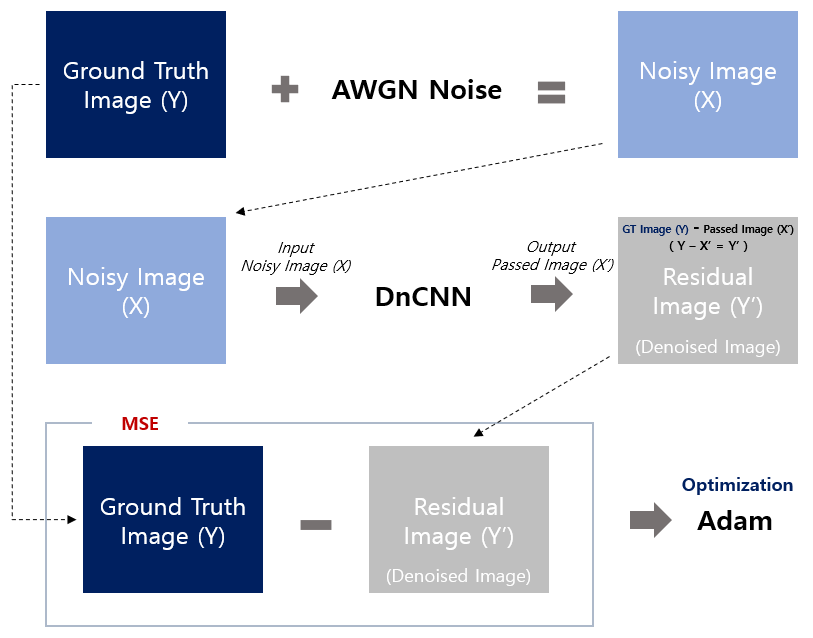

In [8]:
class DnCNN(nn.Module):
    def __init__(
        self,
        channels: int,
        num_of_layers: int,
        kernel_size: int,
        padding: int,
        features: int,
    ):
        super().__init__()

        layers = []
        layers.append(nn.Conv2d(in_channels=channels, out_channels=features, kernel_size=kernel_size, padding=padding, bias=False))
        layers.append(nn.SiLU(inplace=True))

        for _ in range(num_of_layers - 1):
            layers.append(nn.Conv2d(in_channels=features, out_channels=features, kernel_size=kernel_size, padding=padding, bias=False))
            layers.append(nn.GroupNorm(4, features))
            layers.append(nn.SiLU(inplace=True))

        layers.append(nn.Conv2d(in_channels=features, out_channels=channels, kernel_size=kernel_size, padding=padding, bias=False))

        self.dncnn = nn.Sequential(*layers)

    def forward(
        self,
        x: Tensor,
    ) -> Tensor:
        if len(x.shape) != 4:
            raise ValueError(f"Input tensor must be 4D, but got {len(x.shape)}D tensor.")

        out = x + self.dncnn(x)
        return out


# sanity check
_m = DnCNN(channels=1, num_of_layers=3, kernel_size=3, padding=1, features=8)
print("DnCNN out:", _m(torch.randn(1, 1, 64, 64)).shape)
del _m

DnCNN out: torch.Size([1, 1, 64, 64])


## 7. NoiseSimulator

**이미지마다 아래 4종 중 하나를 랜덤으로 골라 `NOISE_RANGES` 범위에서 sigma 를 뽑아** 적용한다.

- Gaussian noise

- Rician noise

- Uniform noise

- Salt and pepper noise

In [9]:
class NoisyType(str, Enum):
    Gaussian = "gaussian"
    Rician = "rician"
    Uniform = "uniform"
    SaltAndPepper = "salt_and_pepper"

    @classmethod
    def from_string(cls, value: str) -> "NoisyType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid NoisyType value: {value}. Must be one of {list(cls)} : {err}") from err


def gaussian_noise(img, sigma: float) -> torch.Tensor:
    noise = torch.randn_like(img) * sigma
    noisy_img = img + noise
    return noisy_img


def rician_noise(img, sigma: float) -> torch.Tensor:
    noise_real = torch.randn_like(img) * sigma
    noise_imag = torch.randn_like(img) * sigma
    noisy_img = torch.abs(img + noise_real + 1j * noise_imag)
    return noisy_img


def uniform_noise(img, sigma: float) -> torch.Tensor:
    noise = (torch.rand_like(img) * 2.0 - 1.0) * sigma
    return img + noise


def salt_and_pepper_noise(img, sigma: float) -> torch.Tensor:
    salt_prob = sigma / 2
    pepper_prob = sigma / 2
    noisy_img = img.clone()
    total_pixels = img.numel()

    # Salt noise
    num_salt = int(total_pixels * salt_prob)
    coords = [torch.randint(0, dim, (num_salt,)) for dim in img.shape]
    noisy_img[tuple(coords)] = img.max()
    # Pepper noise
    num_pepper = int(total_pixels * pepper_prob)
    coords = [torch.randint(0, dim, (num_pepper,)) for dim in img.shape]
    noisy_img[tuple(coords)] = 0  # Set to black

    return noisy_img


class NoiseSimulator:
    """단일 노이즈 타입 + 고정 sigma 를 이미지에 적용한다.

    `RandomNoiseSimulator` 가 (노이즈 종류, sigma) 를 뽑아서 이 클래스에 위임한다.

    구현 근거 (ref/dataset 로 역검증, claude/verify_noise.py 참고):
      - test_label(clean) / test_noise_only(noisy) / noise_meta.json(선언된 type·sigma)를
        비교하면 아래 4개 수식이 실제 데이터 생성기와 일치한다.
        gaussian / uniform / rician 은 오차 < 0.2%, salt&pepper 는 중복 좌표 샘플링까지 재현된다.
      - 생성기는 **clipping 을 하지 않는다.** (gaussian noisy 최소값 -0.298, 최대값 1.359)
        따라서 여기서도 clamp 를 하지 않는다. clamp 를 넣으면 train/test 분포가 어긋난다.
    """

    _DISPATCH: dict[str, Callable[[Tensor, float], Tensor]] = {
        NoisyType.Gaussian.value: gaussian_noise,
        NoisyType.Rician.value: rician_noise,
        NoisyType.Uniform.value: uniform_noise,
        NoisyType.SaltAndPepper.value: salt_and_pepper_noise,
    }

    def __init__(
        self,
        noisy_type: "NoisyType | str",
        sigma: float,
    ) -> None:
        self.noisy_type = noisy_type if isinstance(noisy_type, NoisyType) else NoisyType.from_string(str(noisy_type))
        sigma = float(sigma)
        if sigma < 0.0:
            raise ValueError(f"sigma must be non-negative, got {sigma}")
        self.sigma = sigma

    def __call__(
        self,
        img: Tensor,
    ) -> Tensor:
        if self.sigma == 0.0:
            # sigma=0 이면 노이즈가 없다. 원본을 그대로 쓰면 in-place 오염 위험이 있어 복사한다.
            return img.clone()
        noisy = self._DISPATCH[self.noisy_type.value](img, self.sigma)
        # rician 은 복소수 경유 결과라 dtype 이 바뀔 수 있어 입력 dtype 으로 맞춘다.
        return noisy.to(img.dtype)

    def __repr__(self) -> str:
        return f"NoiseSimulator(noisy_type={self.noisy_type.value}, sigma={self.sigma:.6f})"

class RandomNoiseSimulator:
    def __init__(
        self,
        noise_ranges: dict[str, tuple[float, float]] | None = None,
    ) -> None:
        self.noise_ranges = dict(noise_ranges) if noise_ranges is not None else dict(NOISE_RANGES)
        self.names = list(self.noise_ranges.keys())

    def _sample(self, rng) -> tuple[str, float]:
        name = rng.choice(self.names)
        low, high = self.noise_ranges[name]
        return name, rng.uniform(low, high)

    def __call__(
        self,
        img: torch.Tensor,
        seed: int | None = None,
    ) -> torch.Tensor:
        if seed is None:
            # 학습용: 매번 새로 뽑는다 (같은 이미지도 epoch 마다 다른 노이즈)
            name, sigma = self._sample(random)
            return NoiseSimulator(NoisyType.from_string(name), sigma)(img)

        # 검증/테스트용: 이미지마다 항상 같은 노이즈가 나오도록 seed 를 고정한다
        name, sigma = self._sample(random.Random(seed))
        torch_state = torch.random.get_rng_state()
        torch.manual_seed(seed)
        try:
            noisy = NoiseSimulator(NoisyType.from_string(name), sigma)(img)
        finally:
            torch.random.set_rng_state(torch_state)
        return noisy

    def describe(self, seed: int) -> tuple[str, float]:
        return self._sample(random.Random(seed))


## 8. DataLoader

In [10]:
prob_flip: float = 0.5


class DataKey(IntEnum):
    Label = 0
    Noisy = 1
    Name = 2


@dataclass
class LoaderConfig:
    data_type: str
    batch: int
    num_workers: int
    shuffle: bool
    noisy_type: Literal["random"]
    noise_sigma: float
    noisy_path: str | None = None
    max_images: int | None = None


class DataWrapper(Dataset):
    file_list: list[str]
    training_mode: bool
    noise_simulator: NoiseSimulator

    def __init__(
        self,
        file_path: list[str],
        data_type: str,
        training_mode: bool,
        noisy_type: str,
        noise_sigma: float,
        noisy_path: str | None = None,
        max_images: int | None = None,
    ):
        self.training_mode = training_mode
        self.random_noise = str(noisy_type) == "random"
        if self.random_noise:
            self.noise_simulator = RandomNoiseSimulator()
        else:
            # 고정 노이즈 모드. 원본은 이 경로에서 noise_simulator 가 정의되지 않아 AttributeError 였다.
            self.noise_simulator = NoiseSimulator(NoisyType.from_string(str(noisy_type)), noise_sigma)

        self.noisy_path = Path(noisy_path) if noisy_path is not None else None

        super().__init__()
        total_list: list[str] = []
        for _file_path in file_path:
            total_list += glob.glob(f"{_file_path}/{data_type}")

        total_list = sorted(total_list)
        if max_images is not None:
            total_list = total_list[:max_images]

        self.file_list = total_list

    @staticmethod
    def _load_from_npy(
        file_npy: str,
    ) -> torch.Tensor:
        img = torch.from_numpy(np.load(file_npy)).type(torch.float)
        if len(img.shape) == 2:
            img = img.unsqueeze(0)
        return img

    def _augment(
        self,
        label: torch.Tensor,
        noisy: torch.Tensor | None = None,
    ):
        # label 과 noisy 에 동일한 flip 을 적용한다
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[1])
            noisy = torch.flip(noisy, dims=[1]) if noisy is not None else None
        if random.random() > prob_flip:
            label = torch.flip(label, dims=[2])
            noisy = torch.flip(noisy, dims=[2]) if noisy is not None else None

        return label, noisy

    def __getitem__(
        self,
        idx: int,
    ):
        _name = os.path.basename(self.file_list[idx])  # Windows(\\) / POSIX(/) 모두 대응
        label = self._load_from_npy(self.file_list[idx])

        if self.noisy_path is None:
            if self.training_mode:
                label, _ = self._augment(label)
                noisy = self.noise_simulator(label)
            elif self.random_noise:
                # 검증/테스트는 seed 를 고정
                noisy = self.noise_simulator(label, seed=zlib.crc32(_name.encode()))
            else:
                noisy = self.noise_simulator(label)
        else:
            noisy_file = self.noisy_path / _name
            if not noisy_file.exists():
                raise FileNotFoundError(f"Matching noisy file not found: {noisy_file}")
            noisy = self._load_from_npy(str(noisy_file))
            if self.training_mode:
                label, noisy = self._augment(label, noisy)

        return (
            label,
            noisy,
            _name,
        )

    def __len__(self) -> int:
        return len(self.file_list)


def get_data_wrapper_loader(
    file_path: list[str],
    training_mode: bool,
    loader_cfg: LoaderConfig,
) -> tuple[DataLoader, DataWrapper, int]:
    dataset = DataWrapper(
        file_path=file_path,
        data_type=loader_cfg.data_type,
        training_mode=training_mode,
        noisy_type=loader_cfg.noisy_type,
        noise_sigma=loader_cfg.noise_sigma,
        noisy_path=loader_cfg.noisy_path,
        max_images=loader_cfg.max_images,
    )

    if len(dataset) == 0:
        raise FileNotFoundError(f"No data found in {file_path} with pattern {loader_cfg.data_type}")

    _ = dataset[0]

    dataloader = DataLoader(
        dataset,
        batch_size=loader_cfg.batch,
        num_workers=loader_cfg.num_workers,
        pin_memory=True,
        persistent_workers=loader_cfg.num_workers > 0,
        shuffle=loader_cfg.shuffle,
    )

    return (
        dataloader,
        dataset,
        len(dataset),
    )

### 데이터 확인

train dataset length: 7268
noise: random
  gaussian         sigma 0.0 ~ 0.1
  rician           sigma 0.0 ~ 0.15
  uniform          sigma 0.0 ~ 0.2
  salt_and_pepper  sigma 0.0 ~ 0.2


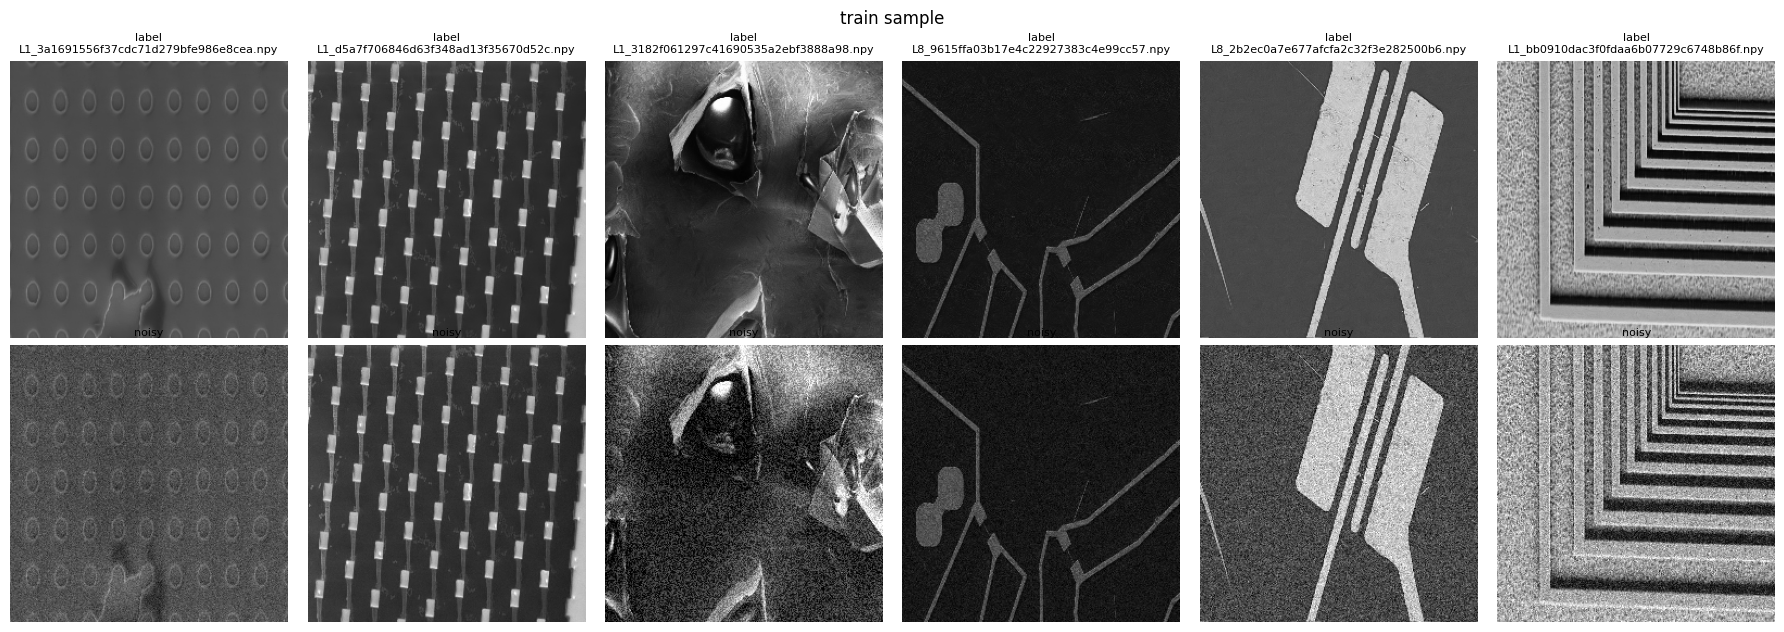

In [11]:
import matplotlib.pyplot as plt

_loader, _, _len = get_data_wrapper_loader(
    file_path=config.train_dataset,
    training_mode=True,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=6,
        num_workers=0,
        shuffle=True,
        noisy_type=config.noise_type,
        noise_sigma=config.noise_sigma,
    ),
)
print(f"train dataset length: {_len}")
print(f"noise: {config.noise_type}")
if config.noise_type == "random":
    for k, v in NOISE_RANGES.items():
        print(f"  {k:16s} sigma {v[0]} ~ {v[1]}")

_label, _noisy, _name = next(iter(_loader))
n = _label.shape[0]
fig, axes = plt.subplots(2, n, figsize=(3 * n, 6.4))
for i in range(n):
    axes[0, i].imshow(_label[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(f"label\n{_name[i]}", fontsize=8)
    axes[0, i].axis("off")
    axes[1, i].imshow(_noisy[i, 0].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].set_title("noisy", fontsize=8)
    axes[1, i].axis("off")
fig.suptitle("train sample")
fig.tight_layout()
plt.show()


## 9. train / test core functions

In [12]:
NETWORK = DnCNN | torch.nn.DataParallel
OPTIM = Adam | AdamW


class ModelType(str, Enum):
    DnCNN = "dncnn"

    @classmethod
    def from_string(cls, value: str) -> "ModelType":
        try:
            return cls(value)
        except ValueError as err:
            raise ValueError(f"Invalid ModelType value: {value}. Must be one of {list(cls)} : {err}") from err


def get_network(
    device: torch.device | None,
    model_type: str,
    dncnnconfig: DnCNNConfig,
) -> NETWORK:
    if device is None:
        raise TypeError("device is not to be None")

    if ModelType.from_string(model_type) == ModelType.DnCNN:
        return DnCNN(
            channels=dncnnconfig.channels,
            num_of_layers=dncnnconfig.num_of_layers,
            kernel_size=dncnnconfig.kernel_size,
            padding=dncnnconfig.padding,
            features=dncnnconfig.features,
        )
    else:
        raise KeyError("model type not matched")


def get_optim(
    network: NETWORK | None,
    optimizer: str,
) -> OPTIM | None:
    if network is None:
        return None
    if optimizer == "adam":
        return Adam(network.parameters(), betas=(0.9, 0.99))
    elif optimizer == "adamw":
        return AdamW(network.parameters(), betas=(0.9, 0.99), weight_decay=0.0)
    else:
        raise KeyError("optimizer not matched")


def get_loss_func(
    loss_model: str,
) -> Callable:
    if loss_model == "l1":
        return torch.nn.L1Loss(reduction="none")
    elif loss_model == "l2":
        return torch.nn.MSELoss(reduction="none")
    else:
        raise KeyError("loss func not matched")


def get_learning_rate(
    epoch: int,
    lr: float,
    lr_decay: float,
    lr_tol: int,
) -> float:
    factor = epoch - lr_tol if lr_tol < epoch else 0
    return lr * (lr_decay**factor)


def set_optimizer_lr(
    optimizer: OPTIM | None,
    learning_rate: float,
) -> OPTIM | None:
    if optimizer is None:
        return None
    for param_group in optimizer.param_groups:
        param_group["lr"] = learning_rate
    return optimizer


def log_summary(
    init_time: float,
    state: MetricController,
    log_std: bool = False,
) -> None:
    spend_time = seconds_to_dhms(time.time() - init_time)
    for key in state.state_dict:
        if log_std:
            summary = f"{spend_time} | {key}: {state.mean(key):0.3e} + {state.std(key):0.3e} "
            logger.info(summary)
        else:
            summary = f"{spend_time} | {key}: {state.mean(key):0.3e}"
            logger.info(summary)


def save_checkpoint(
    network: NETWORK,
    run_dir: Path,
    epoch: str | int | None = None,
) -> None:
    if epoch is None:
        epoch = "best"
    os.makedirs(run_dir / "checkpoints", exist_ok=True)
    torch.save(
        {
            "model_state_dict": network.state_dict(),
            "model_config": asdict(dncnnconfig),
        },
        run_dir / f"checkpoints/checkpoint_{epoch}.ckpt",
    )


def zero_optimizers(
    optim_list: list[OPTIM | None],
) -> None:
    for opt in optim_list:
        if opt is not None:
            opt.zero_grad()


def step_optimizers(
    optim_list: list[OPTIM | None],
) -> None:
    for opt in optim_list:
        if opt is not None:
            opt.step()


def save_result_to_mat(
    test_dir: Path,
    batch_cnt: int,
    tesner_dict: dict[str, Tensor | None],
    img_cnt: int,
) -> None:
    os.makedirs(test_dir, exist_ok=True)
    save_dict = {}

    if batch_cnt == 0:
        logger.warning("batch_cnt is 0, no data to save")
        return

    for i in range(batch_cnt):
        for key, value in tesner_dict.items():
            if value is not None:
                save_dict[key] = value.cpu().detach().numpy()[i, ...]

        idx = img_cnt + i + 1
        savemat(f"{test_dir}/{idx}_res.mat", save_dict)


def train_epoch_dncnn(
    _data,
    network: NETWORK,
    epoch: int,
    train_state: MetricController,
) -> int:
    loss_func = get_loss_func(config.loss_model)

    label: Tensor = _data[DataKey.Label].to(config.device)

    img_cnt_minibatch = label.shape[0]

    output = network.forward(_data[DataKey.Noisy].to(config.device))

    loss = torch.mean(loss_func(output, label), dim=(1, 2, 3), keepdim=True)

    torch.mean(loss).backward()
    train_state.add("loss", loss)

    return img_cnt_minibatch


def train_epoch(
    train_loader: DataLoader,
    train_len: int,
    network: NETWORK,
    optim_list: list[OPTIM | None],
    epoch: int,
) -> float:
    train_state = MetricController()
    train_state.reset()
    network.train()

    logging_cnt: int = 1
    img_cnt: int = 0
    batch_pbar = tqdm(
        train_loader,
        desc=f"  train ep {epoch + 1}",
        unit="batch",
        leave=False,
    )
    for _data in batch_pbar:
        zero_optimizers(optim_list=optim_list)
        if ModelType.from_string(config.model_type) == ModelType.DnCNN:
            img_cnt_minibatch = train_epoch_dncnn(
                _data=_data,
                network=network,
                epoch=epoch,
                train_state=train_state,
            )
        else:
            raise KeyError("model type not matched")

        step_optimizers(optim_list=optim_list)
        img_cnt += img_cnt_minibatch
        batch_pbar.set_postfix(loss=f"{train_state.mean('loss'):0.3e}")
        if img_cnt > (train_len / config.logging_density * logging_cnt):
            log_summary(init_time=config.init_time, state=train_state)
            logging_cnt += 1

    log_summary(init_time=config.init_time, state=train_state)
    return float(train_state.mean("loss"))


def test_part_dncnn(
    _data,
    test_dir: Path,
    model: NETWORK,
    save_val: bool,
    test_state: MetricController,
    img_cnt: int,
) -> int:
    noisy = _data[DataKey.Noisy].to(config.device)
    label = _data[DataKey.Label].to(config.device)

    batch_cnt = noisy.shape[0]

    validate_tensors([noisy, label])
    validate_tensor_dimensions([noisy, label], 4)

    output = model(noisy)

    validate_tensors([output])
    validate_tensor_dimensions([output], 4)

    for idx in range(output.shape[0]):
        test_state.add("psnr", calculate_psnr(output[idx : idx + 1, ...], label[idx : idx + 1, ...]))
        test_state.add("ssim", calculate_ssim(output[idx : idx + 1, ...], label[idx : idx + 1, ...]))

    if save_val:
        save_result_to_mat(
            test_dir=test_dir,
            batch_cnt=batch_cnt,
            tesner_dict={
                "noisy": noisy,
                "output": output,
                "label": label,
            },
            img_cnt=img_cnt,
        )

    return batch_cnt


def test_part(
    epoch: int,
    data_loader: DataLoader,
    network: NETWORK,
    run_dir: Path,
    save_val: bool,
    desc: str = "valid",
) -> float:
    test_state = MetricController()
    test_state.reset()
    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network

    img_cnt: int = 0
    batch_pbar = tqdm(data_loader, desc=f"  {desc}", unit="batch", leave=False)
    for _data in batch_pbar:
        if ModelType.from_string(config.model_type) == ModelType.DnCNN:
            batch_cnt = test_part_dncnn(
                _data=_data,
                test_dir=run_dir / f"test/ep_{epoch}",
                model=model,
                save_val=save_val and img_cnt <= config.save_max_idx,
                test_state=test_state,
                img_cnt=img_cnt,
            )
        else:
            raise KeyError("model type not matched")

        img_cnt += batch_cnt
        batch_pbar.set_postfix(psnr=f"{test_state.mean('psnr'):0.2f}")

    log_summary(init_time=config.init_time, state=test_state, log_std=True)

    primary_metric = test_state.mean("psnr")
    return primary_metric

## 10. Validation 결과 시각화


저장 위치: `{run_dir}/valid_png/ep_{epoch}/{파일명}.png`

In [13]:
import matplotlib.pyplot as plt

VALID_FIG_MAX: int = 4  # validation 마다 저장할 이미지 수


def save_comparison_figures(
    epoch: int,
    data_loader: DataLoader,
    network: NETWORK,
    run_dir: Path,
    max_images: int = VALID_FIG_MAX,
    tag: str = "valid",
    subdir: str | None = None,
    noise_lookup: dict[str, str] | None = None,
    title_prefix: str | None = None,
) -> Path:
    save_dir = run_dir / (subdir if subdir is not None else f"{tag}_png/ep_{epoch:03d}")
    os.makedirs(save_dir, exist_ok=True)

    network.eval()
    model = network.module if isinstance(network, torch.nn.DataParallel) else network
    dataset = data_loader.dataset

    saved = 0
    with torch.no_grad():
        for _data in data_loader:
            label = _data[DataKey.Label].to(config.device)
            noisy = _data[DataKey.Noisy].to(config.device)
            names = _data[DataKey.Name]

            output = model(noisy)

            for i in range(output.shape[0]):
                if saved >= max_images:
                    break

                lab_i, noi_i, out_i = label[i : i + 1], noisy[i : i + 1], output[i : i + 1]
                psnr_in = calculate_psnr(noi_i, lab_i).item()
                ssim_in = calculate_ssim(noi_i, lab_i).item()
                psnr_out = calculate_psnr(out_i, lab_i).item()
                ssim_out = calculate_ssim(out_i, lab_i).item()

                lab = lab_i.cpu().numpy().squeeze()
                noi = noi_i.cpu().numpy().squeeze()
                out = out_i.cpu().numpy().squeeze()
                err = np.abs(out - lab)

                vmax = float(np.percentile(lab, 98) * 1.2)
                err_vmax = float(max(err.max(), 1e-6))

                fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
                panels = [
                    (lab, "Original (label)", "gray", 0.0, vmax),
                    (noi, f"Noisy\nPSNR {psnr_in:.2f} dB / SSIM {ssim_in:.4f}", "gray", 0.0, vmax),
                    (out, f"Denoised\nPSNR {psnr_out:.2f} dB / SSIM {ssim_out:.4f}", "gray", 0.0, vmax),
                    (err, f"Error |denoised - label|\nmax {err_vmax:.3f}", "magma", 0.0, err_vmax),
                ]
                for ax, (img, title, cmap, lo, hi) in zip(axes, panels):
                    im = ax.imshow(img, cmap=cmap, vmin=lo, vmax=hi)
                    ax.set_title(title, fontsize=10)
                    ax.axis("off")
                fig.colorbar(im, ax=axes[3], fraction=0.046, pad=0.02)

                noise_desc = ""
                if getattr(dataset, "random_noise", False) and dataset.noisy_path is None:
                    _nz, _sg = dataset.noise_simulator.describe(zlib.crc32(names[i].encode()))
                    noise_desc = f" | noise={_nz} sigma={_sg:.4f}"
                elif noise_lookup:
                    noise_desc = f" | noise={noise_lookup.get(names[i], 'unknown')}"

                fig.suptitle(
                    f"{title_prefix if title_prefix is not None else f'epoch {epoch}'}"
                    f" | {names[i]}{noise_desc}"
                    f" | PSNR {psnr_in:.2f} -> {psnr_out:.2f} dB",
                    fontsize=11,
                )
                fig.tight_layout(rect=(0, 0, 1, 0.90))
                fig.savefig(save_dir / f"{names[i].replace('.npy', '')}.png", dpi=150, bbox_inches="tight")
                plt.close(fig)
                saved += 1

            if saved >= max_images:
                break

    logger.info(f"Saved {saved} comparison figures to {save_dir}")
    return save_dir

## 11. Train

In [14]:
class Trainer:
    run_dir: Path
    network: NETWORK
    train_loader: DataLoader
    train_len: int
    valid_loader: DataLoader
    optims: list[OPTIM | None]

    def __init__(
        self,
    ) -> None:
        config.init_time = time.time()
        config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(config.device)

        # dir setting
        self.run_dir = config.run_dir / f"{call_next_id(config.run_dir):05d}_train"
        logger_add_handler(logger, f"{self.run_dir/'log.log'}", config.log_lv)
        logger.info(separator())
        logger.info(f"Run dir: {self.run_dir}")
        os.makedirs(self.run_dir, exist_ok=True)

        # log config
        logger.info(separator())
        logger.info("General Config")
        config_dict = asdict(config)
        for k in config_dict:
            logger.info(f"{k}:{config_dict[k]}")
        logger.info(separator())
        logger.info("Model Config")
        config_dict = asdict(dncnnconfig)
        for k in config_dict:
            logger.info(f"{k}:{config_dict[k]}")

    def __call__(
        self,
    ) -> None:
        self._set_data()
        self._set_network()
        self._train()

    @error_wrap
    def _set_data(
        self,
    ) -> None:
        logger.info(separator())
        train_loader_cfg = LoaderConfig(
            data_type=config.data_type,
            batch=config.train_batch,
            num_workers=config.num_workers,
            shuffle=True,
            noisy_type=config.noise_type,
            noise_sigma=config.noise_sigma,
            max_images=config.max_train_images,
        )

        valid_loader_cfg = LoaderConfig(
            data_type=config.data_type,
            batch=config.valid_batch,
            num_workers=config.num_workers,
            shuffle=False,
            noisy_type=config.noise_type,
            noise_sigma=config.noise_sigma,
            max_images=config.max_valid_images,
        )

        self.train_loader, _, self.train_len = get_data_wrapper_loader(
            file_path=config.train_dataset,
            training_mode=True,
            loader_cfg=train_loader_cfg,
        )
        logger.info(f"Train dataset length : {self.train_len}")

        self.valid_loader, _, valid_len = get_data_wrapper_loader(
            file_path=config.valid_dataset,
            training_mode=False,
            loader_cfg=valid_loader_cfg,
        )
        logger.info(f"Valid dataset length : {valid_len}")

    @error_wrap
    def _set_network(
        self,
    ) -> None:
        self.network = get_network(
            device=config.device,
            model_type=config.model_type,
            dncnnconfig=dncnnconfig,
        )

        self.optims = [
            get_optim(
                network=self.network,
                optimizer=config.optimizer,
            ),
        ]

        if config.parallel:
            self.network = torch.nn.DataParallel(self.network).to(config.device)
        else:
            self.network = self.network.to(config.device)

    @error_wrap
    def _train(
        self,
    ) -> None:
        logger.info(separator())
        logger.info("Train start")

        best_metric: float = 0
        primary_metric: float = 0
        postfix: dict[str, str] = {}
        epoch_pbar = tqdm(
            range(config.train_epoch),
            desc="Epoch",
            unit="epoch",
            leave=True,
        )

        for epoch in epoch_pbar:
            lr_epoch = get_learning_rate(
                epoch=epoch,
                lr=config.lr,
                lr_decay=config.lr_decay,
                lr_tol=config.lr_tol,
            )
            postfix["lr"] = f"{lr_epoch:0.3e}"
            epoch_pbar.set_postfix(postfix)
            tqdm.write(f"Epoch {epoch + 1}/{config.train_epoch} | lr={lr_epoch:0.3e}")

            optims = [set_optimizer_lr(optimizer=optim, learning_rate=lr_epoch) for optim in self.optims]

            train_loss = train_epoch(
                train_loader=self.train_loader,
                train_len=self.train_len,
                network=self.network,
                optim_list=optims,
                epoch=epoch,
            )
            postfix["loss"] = f"{train_loss:0.3e}"
            epoch_pbar.set_postfix(postfix)

            save_checkpoint(
                network=self.network,
                run_dir=self.run_dir,
                epoch=epoch,
            )

            if epoch < config.valid_tol:
                continue

            if epoch % config.valid_interval == 0:
                primary_metric = self._valid(epoch)
                if primary_metric is not None:
                    postfix["val_psnr"] = f"{primary_metric:0.2f}"
                    epoch_pbar.set_postfix(postfix)

            # best 기준은 validation PSNR
            if primary_metric is not None and primary_metric > best_metric:
                best_metric = primary_metric
                logger.success(f"Best model renew (valid psnr {best_metric:0.4f})")
                save_checkpoint(
                    network=self.network,
                    run_dir=self.run_dir,
                )

    @error_wrap
    def _valid(
        self,
        epoch: int,
    ) -> float:
        logger.info("Valid")
        with torch.no_grad():
            primary_metric = test_part(
                epoch=epoch,
                data_loader=self.valid_loader,
                network=self.network,
                run_dir=self.run_dir,
                save_val=False,
                desc=f"valid ep {epoch + 1}",
            )

        # validation 이 끝날 때마다 비교 이미지를 png 로 남긴다.
        try:
            save_comparison_figures(
                epoch=epoch,
                data_loader=self.valid_loader,
                network=self.network,
                run_dir=self.run_dir,
            )
        except Exception as err:
            logger.warning(f"Failed to save validation figures: {err}")

        return primary_metric

### 학습 실행

In [15]:
trainer = Trainer()
trainer()

TRAIN_RUN_DIR = trainer.run_dir
print("train run dir:", TRAIN_RUN_DIR)

cuda
2026-08-31 05:26:28 [INFO] ####################################################################################################
2026-08-31 05:26:28 [INFO] Run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train
2026-08-31 05:26:28 [INFO] ####################################################################################################
2026-08-31 05:26:28 [INFO] General Config
2026-08-31 05:26:28 [INFO] train_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/train']
2026-08-31 05:26:28 [INFO] valid_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/val']
2026-08-31 05:26:28 [INFO] test_dataset:['/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label']
2026-08-31 05:26:28 [INFO] data_type:*.npy
2026-08-31 05:26:28 [INFO] test_noisy_dir:/content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only
2026-08-31 05:26:28 [INFO] log_lv:I

Epoch:   0%|          | 0/10 [00:00<?, ?epoch/s]

Epoch 1/10 | lr=1.000e-04


  train ep 1:   0%|          | 0/455 [00:00<?, ?batch/s]

2026-08-31 05:30:11 [INFO] 00h 03m 43s | loss: 1.162e-02
2026-08-31 05:30:38 [INFO] 00h 04m 09s | loss: 8.042e-03
2026-08-31 05:31:03 [INFO] 00h 04m 34s | loss: 6.505e-03
2026-08-31 05:31:28 [INFO] 00h 05m 00s | loss: 5.652e-03
2026-08-31 05:31:28 [INFO] Valid


...

2026-08-31 05:42:23 [INFO] 00h 15m 54s | psnr: 3.027e+01 + 4.139e+00 
2026-08-31 05:42:23 [INFO] 00h 15m 54s | ssim: 8.356e-01 + 1.178e-01 
2026-08-31 05:42:27 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png/ep_008
Epoch 10/10 | lr=3.596e-05


  train ep 10:   0%|          | 0/455 [00:00<?, ?batch/s]

2026-08-31 05:42:45 [INFO] 00h 16m 17s | loss: 1.213e-03
2026-08-31 05:43:03 [INFO] 00h 16m 35s | loss: 1.210e-03
2026-08-31 05:43:21 [INFO] 00h 16m 52s | loss: 1.213e-03
2026-08-31 05:43:39 [INFO] 00h 17m 10s | loss: 1.185e-03
2026-08-31 05:43:39 [INFO] Valid


  valid ep 10:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-08-31 05:43:41 [INFO] 00h 17m 12s | psnr: 3.057e+01 + 4.365e+00 
2026-08-31 05:43:41 [INFO] 00h 17m 12s | ssim: 8.349e-01 + 1.185e-01 
2026-08-31 05:43:45 [INFO] Saved 4 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png/ep_009
train run dir: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train


## 학습 결과

best checkpoint 는 **validation PSNR** 이 가장 높았던 시점의 가중치이고,
`{run_dir}/checkpoints/checkpoint_best.ckpt` 에 저장된다.


In [16]:
best_ckpt = TRAIN_RUN_DIR / "checkpoints/checkpoint_best.ckpt"
print("best checkpoint:", best_ckpt, "| exists:", best_ckpt.exists())

valid_pngs = sorted((TRAIN_RUN_DIR / "valid_png").rglob("*.png"))
print(f"validation figures: {len(valid_pngs)} png in {TRAIN_RUN_DIR / 'valid_png'}")
for p in valid_pngs[-4:]:
    print(" ", p)


best checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/checkpoints/checkpoint_best.ckpt | exists: True
validation figures: 40 png in /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png/ep_009/L1_04e524d382fc4f1aecdf6bbf39bd5b0f.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png/ep_009/L1_0aceacb0b3bbb83e38dd3f314b5b61b8.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png/ep_009/L1_0b01fddd63d7c84949f7439279d7bd21.png
  /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/valid_png/ep_009/L1_0b8e81c4fb1673f558be432fc1e3360f.png


## 12. 학습이 끝난 뒤 테스트 (best checkpoint)

학습 중에는 validation 만 돌고, test 는 여기서 **best checkpoint 로 한 번만** 돌린다.
(best 는 validation PSNR 기준으로 고른 가중치다.)


결과물: `{run_dir}/test_metrics.json` (영상별 지표), `{run_dir}/test_png/*.png` (비교 이미지)

In [17]:
TEST_MAX_FIG: int = 8  # 저장할 비교 이미지 수

TEST_RUN_DIR = globals().get("TRAIN_RUN_DIR")
if TEST_RUN_DIR is None:
    raise RuntimeError("학습 셀을 먼저 실행하거나 TEST_RUN_DIR 을 직접 지정할 것 (예: RUN_DIR / '00000_train')")

BEST_CKPT = TEST_RUN_DIR / "checkpoints/checkpoint_best.ckpt"

if config.device is None:
    config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if config.init_time == 0.0:
    config.init_time = time.time()


def load_checkpoint_network(
    ckpt_path: Path,
    device: torch.device,
) -> DnCNN:
    checkpoint_data = torch.load(ckpt_path, map_location="cpu", weights_only=True)

    if not (("model_state_dict" in checkpoint_data) and ("model_config" in checkpoint_data)):
        raise KeyError(f"Invalid checkpoint: {ckpt_path}")

    modelconfig = DnCNNConfig(**checkpoint_data["model_config"])
    network = DnCNN(
        channels=modelconfig.channels,
        num_of_layers=modelconfig.num_of_layers,
        kernel_size=modelconfig.kernel_size,
        padding=modelconfig.padding,
        features=modelconfig.features,
    )

    _state_dict = {k.replace("module.", ""): v for k, v in checkpoint_data["model_state_dict"].items()}
    network.load_state_dict(_state_dict, strict=True)

    logger.info(f"Loaded checkpoint: {ckpt_path}")
    for k, v in asdict(modelconfig).items():
        logger.info(f"{k}:{v}")

    return network.to(device).eval()


test_network = load_checkpoint_network(BEST_CKPT, config.device)

test_loader, _, test_len = get_data_wrapper_loader(
    file_path=config.test_dataset,
    training_mode=False,
    loader_cfg=LoaderConfig(
        data_type=config.data_type,
        batch=config.valid_batch,
        num_workers=config.num_workers,
        shuffle=False,
        noisy_type=config.noise_type,
        noise_sigma=config.noise_sigma,
        noisy_path=config.test_noisy_dir,
    ),
)
print(f"checkpoint : {BEST_CKPT}")
print(f"label      : {config.test_dataset[0]}")
print(f"noisy      : {config.test_noisy_dir or f'on-the-fly ({config.noise_type})'}")
print(f"test images: {test_len}")

2026-08-31 05:43:45 [INFO] Loaded checkpoint: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/checkpoints/checkpoint_best.ckpt
2026-08-31 05:43:45 [INFO] channels:1
2026-08-31 05:43:45 [INFO] num_of_layers:17
2026-08-31 05:43:45 [INFO] kernel_size:3
2026-08-31 05:43:45 [INFO] padding:1
2026-08-31 05:43:45 [INFO] features:64
checkpoint : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/checkpoints/checkpoint_best.ckpt
label      : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_label
noisy      : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/dataset/test_noise_only/test_noise_only
test images: 100


In [18]:
noise_lookup: dict[str, str] = {}
if config.test_noisy_dir is not None:
    _meta = Path(config.test_noisy_dir) / "noise_meta.json"
    if _meta.exists():
        with open(_meta) as f:
            noise_lookup = {r["file"]: r["noise_type"] for r in json.load(f)}
        print(f"noise_meta.json: {len(noise_lookup)} entries")

test_state = MetricController()
test_state.reset()
rows: list[dict] = []

with torch.no_grad():
    for _data in tqdm(test_loader, desc="test", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        noisy = _data[DataKey.Noisy].to(config.device)
        names = _data[DataKey.Name]

        output = test_network(noisy)

        for i in range(output.shape[0]):
            out_i, lab_i, noi_i = output[i : i + 1], label[i : i + 1], noisy[i : i + 1]
            psnr_out = calculate_psnr(out_i, lab_i)
            ssim_out = calculate_ssim(out_i, lab_i)
            test_state.add("psnr", psnr_out)
            test_state.add("ssim", ssim_out)
            rows.append(
                {
                    "file": names[i],
                    "noise_type": noise_lookup.get(names[i], "unknown"),
                    "psnr": psnr_out.item(),
                    "ssim": ssim_out.item(),
                    "psnr_in": calculate_psnr(noi_i, lab_i).item(),
                    "ssim_in": calculate_ssim(noi_i, lab_i).item(),
                }
            )

log_summary(init_time=config.init_time, state=test_state, log_std=True)

with open(TEST_RUN_DIR / "test_metrics.json", "w") as f:
    json.dump(rows, f, indent=2)

print()
print(f"{'noise':<18}{'n':>5}{'PSNR in':>10}{'PSNR out':>10}{'SSIM in':>10}{'SSIM out':>10}")
print("-" * 63)
for nz in [*NOISE_RANGES.keys(), "unknown"]:
    sub = [r for r in rows if r["noise_type"] == nz]
    if not sub:
        continue
    print(
        f"{nz:<18}{len(sub):>5}"
        f"{np.mean([r['psnr_in'] for r in sub]):>10.3f}"
        f"{np.mean([r['psnr'] for r in sub]):>10.3f}"
        f"{np.mean([r['ssim_in'] for r in sub]):>10.4f}"
        f"{np.mean([r['ssim'] for r in sub]):>10.4f}"
    )
print("-" * 63)
print(
    f"{'ALL':<18}{len(rows):>5}"
    f"{np.mean([r['psnr_in'] for r in rows]):>10.3f}"
    f"{np.mean([r['psnr'] for r in rows]):>10.3f}"
    f"{np.mean([r['ssim_in'] for r in rows]):>10.4f}"
    f"{np.mean([r['ssim'] for r in rows]):>10.4f}"
)

test_png_dir = save_comparison_figures(
    epoch=0,
    data_loader=test_loader,
    network=test_network,
    run_dir=TEST_RUN_DIR,
    max_images=TEST_MAX_FIG,
    subdir="test_png",
    noise_lookup=noise_lookup,
    title_prefix="test (best ckpt)",
)
print(f"\nmetrics : {TEST_RUN_DIR / 'test_metrics.json'}")
print(f"figures : {test_png_dir}")

noise_meta.json: 100 entries


test:   0%|          | 0/100 [00:00<?, ?batch/s]

2026-08-31 05:44:51 [INFO] 00h 18m 23s | psnr: 3.059e+01 + 4.779e+00 
2026-08-31 05:44:51 [INFO] 00h 18m 23s | ssim: 8.947e-01 + 8.365e-02 

noise                 n   PSNR in  PSNR out   SSIM in  SSIM out
---------------------------------------------------------------
gaussian             25    27.668    32.282    0.6835    0.8963
rician               25    24.079    28.727    0.7104    0.8632
uniform              25    29.631    32.060    0.7950    0.9279
salt_and_pepper      25    17.304    29.298    0.4746    0.8915
---------------------------------------------------------------
ALL                 100    24.671    30.592    0.6659    0.8947
2026-08-31 05:44:59 [INFO] Saved 8 comparison figures to /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/test_png

metrics : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/test_metrics.json
figures : /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denois

### 저장된 test 결과 이미지

In [19]:
from IPython.display import Image, display

for p in sorted(test_png_dir.glob("*.png"))[:3]:
    print(p.name)
    display(Image(filename=str(p)))

Output hidden; open in https://colab.research.google.com to view.

## 13. 베이스라인 비교 (mean filter / median filter)

conventional filter와 학습한 DnCNN 비교

| 방법 | 원본 | 설명 |
|---|---|---|
| DnCNN | `model/dncnn.py` | 학습된 best checkpoint |
| mean filter | `filter/mean_filter.py` | 3x3 이웃 평균 |
| median filter | `filter/median_filter.py` | 3x3 이웃 중앙값 (salt & pepper 에 강함) |

세 방법 모두 **같은 test 데이터(`test_noise_only`)** 에 대해 PSNR / SSIM 을 잰다.


In [20]:
def _as_bchw(img: Tensor) -> tuple[Tensor, int]:
    """[H,W] / [C,H,W] / [B,C,H,W] 를 모두 [B,C,H,W] 로 맞춘다."""
    dim = img.dim()
    if dim == 2:
        return img[None, None], dim
    if dim == 3:
        return img[None], dim
    if dim == 4:
        return img, dim
    raise ValueError(f"unsupported image dim: {dim}")


def _restore_dim(img: Tensor, dim: int) -> Tensor:
    if dim == 2:
        return img[0, 0]
    if dim == 3:
        return img[0]
    return img


def mean_filter(
    img: Tensor,
    kernel_size: int = 3,
) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    out = functional.avg_pool2d(x, kernel_size=kernel_size, stride=1)
    return _restore_dim(out, dim)


def median_filter(
    img: Tensor,
    kernel_size: int = 3,
) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    x = functional.pad(x, (pad, pad, pad, pad), mode="reflect")
    # [B, C, H, W, k, k] -> 마지막 k*k 축에서 중앙값
    patches = x.unfold(2, kernel_size, 1).unfold(3, kernel_size, 1)
    out = patches.reshape(*patches.shape[:4], -1).median(dim=-1).values
    return _restore_dim(out, dim)


def adaptive_filter(
    img: Tensor,
    kernel_size: int = 5,
    noise_var: Tensor | float | None = None,
) -> Tensor:
    x, dim = _as_bchw(img)
    pad = kernel_size // 2
    xp = functional.pad(x, (pad, pad, pad, pad), mode="reflect")

    local_mean = functional.avg_pool2d(xp, kernel_size=kernel_size, stride=1)
    local_sq = functional.avg_pool2d(xp.pow(2), kernel_size=kernel_size, stride=1)
    local_var = (local_sq - local_mean.pow(2)).clamp_min(0.0)

    if noise_var is None:
        noise_var = local_var.flatten(2).median(dim=-1).values[:, :, None, None]

    ratio = (noise_var / local_var.clamp_min(1e-8)).clamp(max=1.0)
    out = x - ratio * (x - local_mean)
    return _restore_dim(out, dim)

In [21]:
BASELINE_KERNEL: int = 3
ADAPTIVE_KERNEL: int = 5

METHODS: list[str] = ["noisy", "dncnn", "mean", "median", "adaptive"]
METHOD_LABEL: dict[str, str] = {
    "noisy": "Noisy (input)",
    "dncnn": "DnCNN (best)",
    "mean": f"Mean {BASELINE_KERNEL}x{BASELINE_KERNEL}",
    "median": f"Median {BASELINE_KERNEL}x{BASELINE_KERNEL}",
    "adaptive": f"Adaptive {ADAPTIVE_KERNEL}x{ADAPTIVE_KERNEL}",
}

baseline_rows: list[dict] = []
noise_samples: dict[str, dict] = {}

test_network.eval()
with torch.no_grad():
    for _data in tqdm(test_loader, desc="baseline", unit="batch"):
        label = _data[DataKey.Label].to(config.device)
        noisy = _data[DataKey.Noisy].to(config.device)
        names = _data[DataKey.Name]

        outputs = {
            "noisy": noisy,
            "dncnn": test_network(noisy),
            "mean": mean_filter(noisy, kernel_size=BASELINE_KERNEL),
            "median": median_filter(noisy, kernel_size=BASELINE_KERNEL),
            "adaptive": adaptive_filter(noisy, kernel_size=ADAPTIVE_KERNEL),
        }

        for i in range(label.shape[0]):
            lab_i = label[i : i + 1]
            row = {"file": names[i], "noise_type": noise_lookup.get(names[i], "unknown")}
            for key in METHODS:
                pred_i = outputs[key][i : i + 1]
                row[f"psnr_{key}"] = calculate_psnr(pred_i, lab_i).item()
                row[f"ssim_{key}"] = calculate_ssim(pred_i, lab_i).item()
            baseline_rows.append(row)

            if row["noise_type"] not in noise_samples:
                sample = {"name": names[i], "metrics": row, "label": lab_i.cpu().numpy().squeeze()}
                for key in METHODS:
                    sample[key] = outputs[key][i : i + 1].cpu().numpy().squeeze()
                noise_samples[row["noise_type"]] = sample


def print_baseline_table(metric: str, width: int = 15) -> None:
    fmt = ".3f" if metric == "psnr" else ".4f"
    print(f"[{metric.upper()}]")
    print(f"{'noise':<18}{'n':>5}" + "".join(f"{METHOD_LABEL[m]:>{width}}" for m in METHODS))
    print("-" * (23 + width * len(METHODS)))
    for nz in [*NOISE_RANGES.keys(), "unknown"]:
        sub = [r for r in baseline_rows if r["noise_type"] == nz]
        if not sub:
            continue
        cells = "".join(f"{np.mean([r[f'{metric}_{m}'] for r in sub]):>{width}{fmt}}" for m in METHODS)
        print(f"{nz:<18}{len(sub):>5}{cells}")
    print("-" * (23 + width * len(METHODS)))
    cells = "".join(f"{np.mean([r[f'{metric}_{m}'] for r in baseline_rows]):>{width}{fmt}}" for m in METHODS)
    print(f"{'ALL':<18}{len(baseline_rows):>5}{cells}")


print()
print_baseline_table("psnr")
print()
print_baseline_table("ssim")

with open(TEST_RUN_DIR / "baseline_metrics.json", "w") as f:
    json.dump(baseline_rows, f, indent=2)
print(f"\nmetrics : {TEST_RUN_DIR / 'baseline_metrics.json'}")

baseline:   0%|          | 0/100 [00:00<?, ?batch/s]


[PSNR]
noise                 n  Noisy (input)   DnCNN (best)       Mean 3x3     Median 3x3   Adaptive 5x5
--------------------------------------------------------------------------------------------------
gaussian             25         27.668         32.282         26.316         27.382         30.078
rician               25         24.079         28.727         23.669         24.080         27.046
uniform              25         29.631         32.060         26.263         26.779         30.521
salt_and_pepper      25         17.304         29.298         23.196         28.496         21.164
--------------------------------------------------------------------------------------------------
ALL                 100         24.671         30.592         24.861         26.684         27.202

[SSIM]
noise                 n  Noisy (input)   DnCNN (best)       Mean 3x3     Median 3x3   Adaptive 5x5
---------------------------------------------------------------------------------------------

### 노이즈 종류별 결과 비교 (4 x 8)

saved: /content/drive/MyDrive/DS2026/20260831-pjt5-이종호/실습/logs_denoising/00000_train/baseline_grid.png


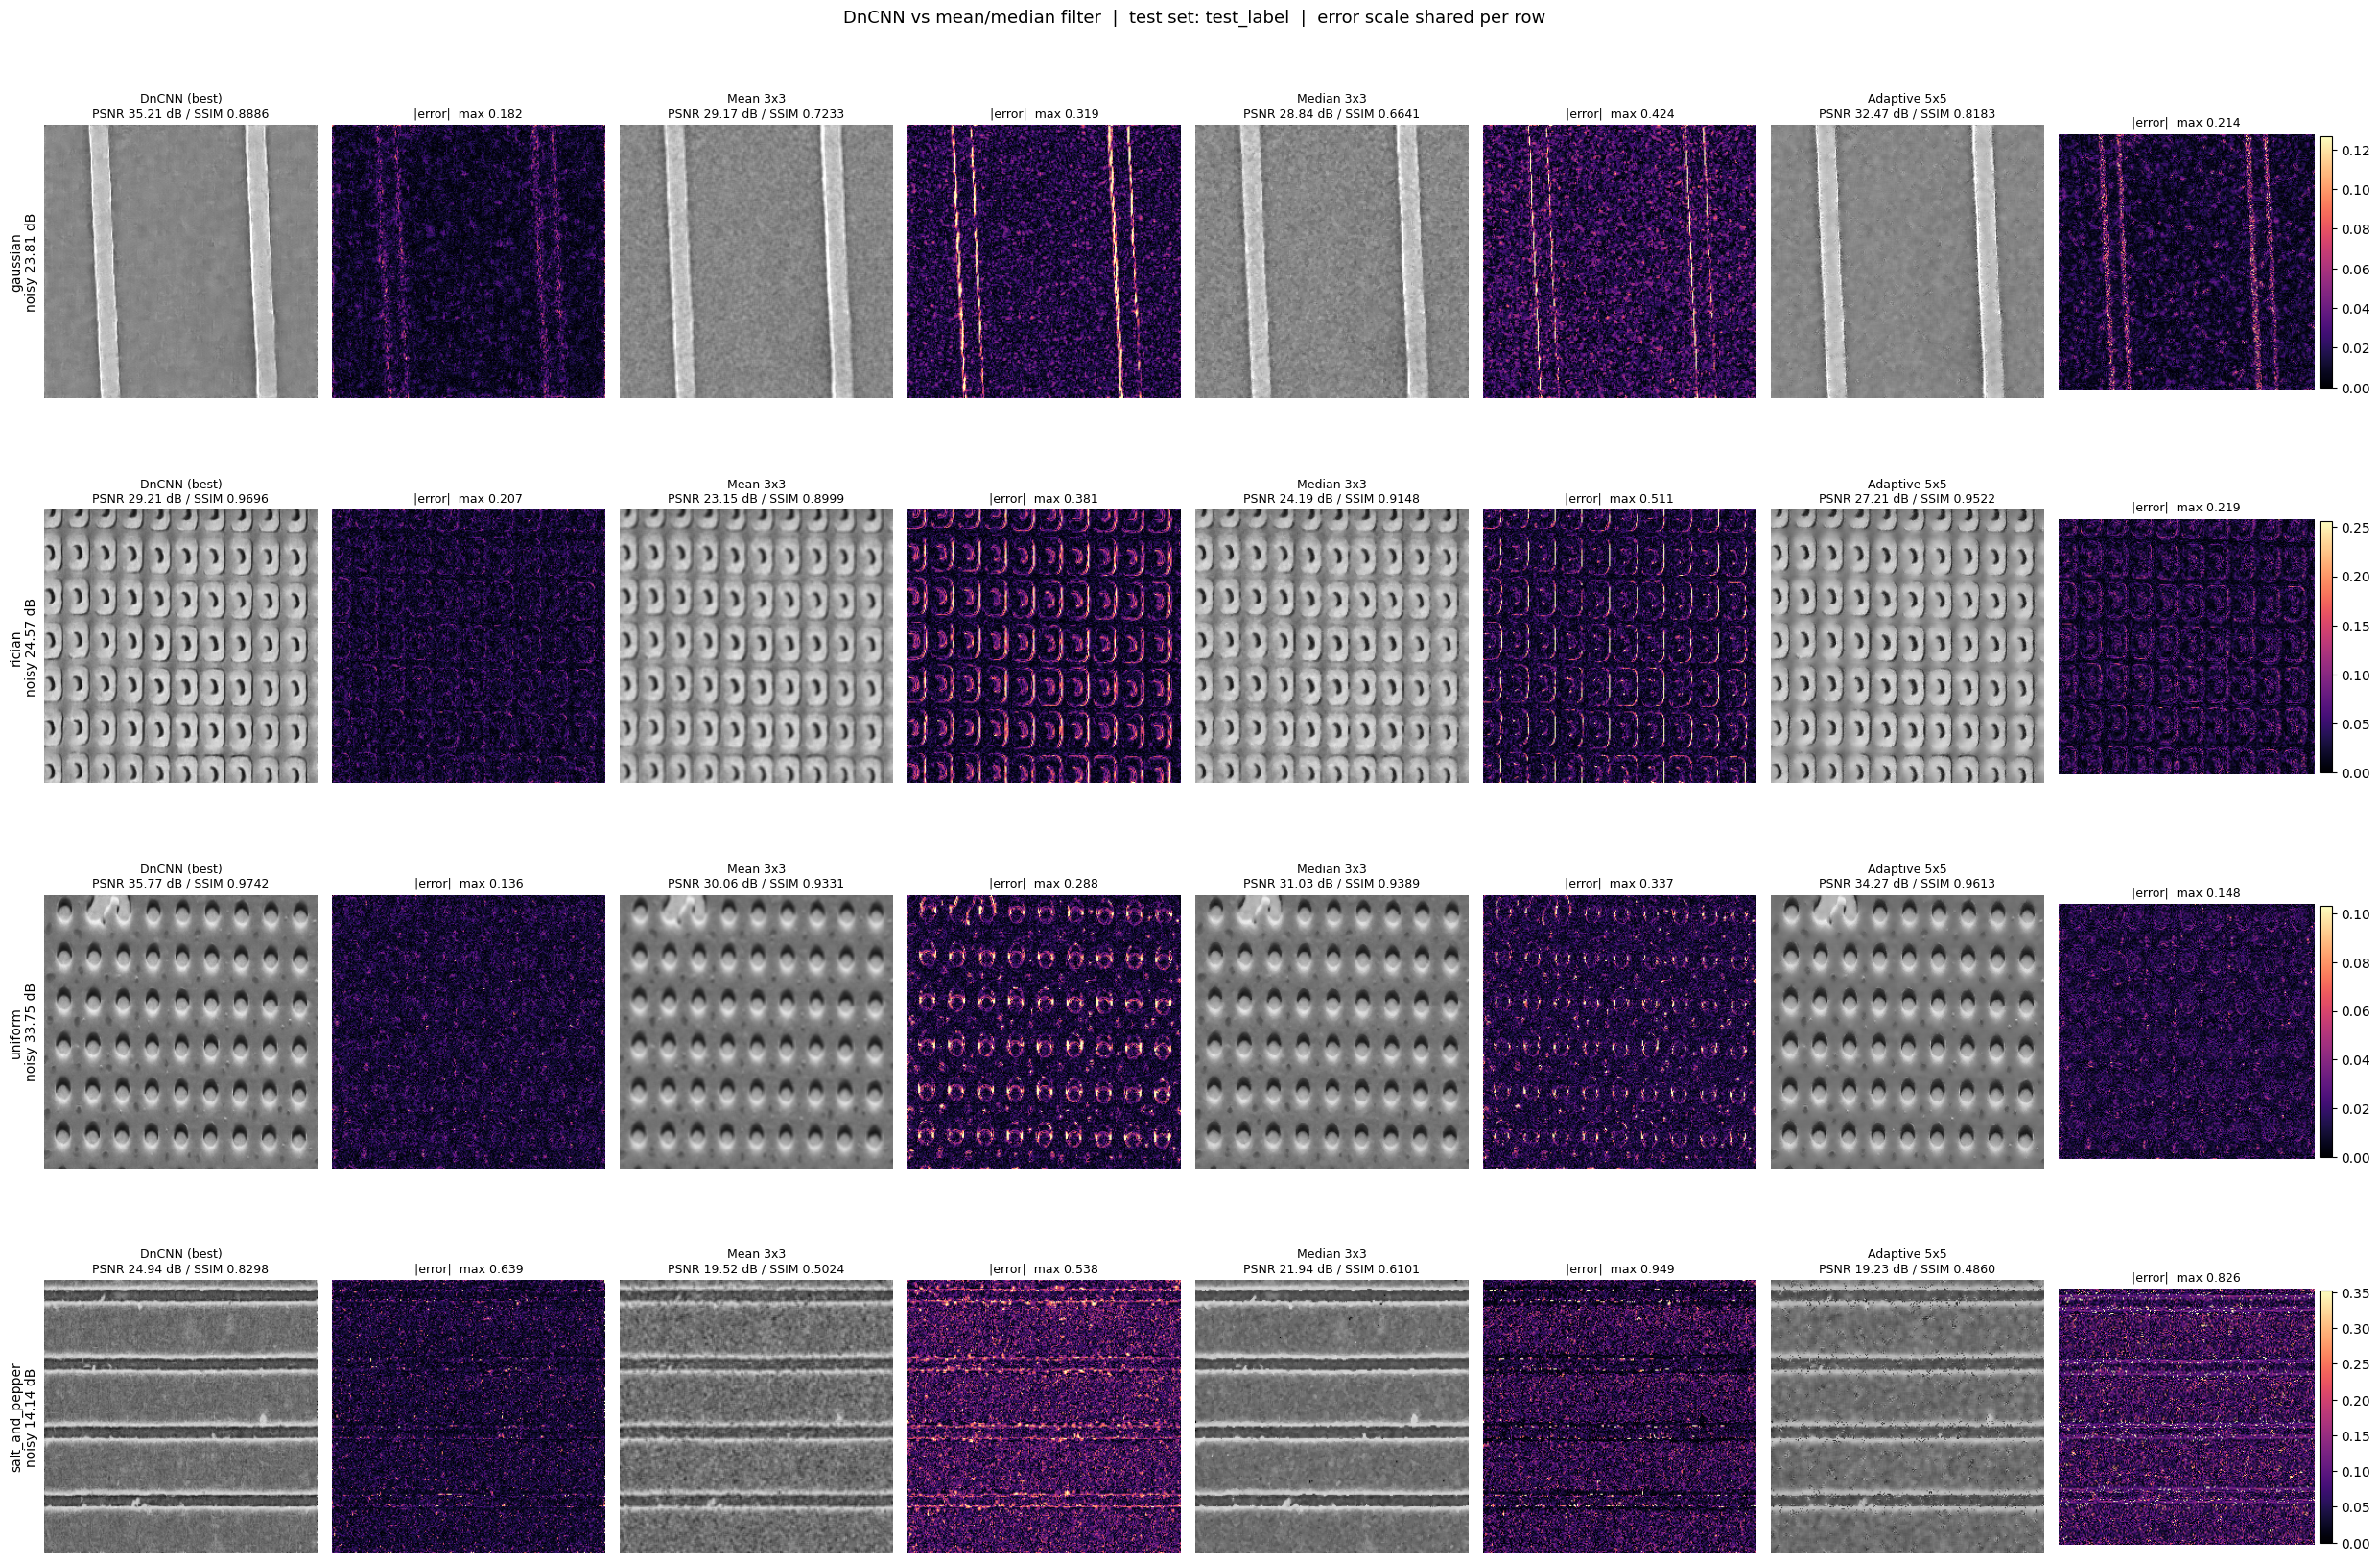

In [22]:
ERROR_CMAP = "magma"
GRID_COLS = ["dncnn", "mean", "median", "adaptive"]

row_order = [nz for nz in [*NOISE_RANGES.keys(), "unknown"] if nz in noise_samples]
if not row_order:
    raise RuntimeError("noise_samples 가 비어 있다. 앞의 baseline 셀을 먼저 실행할 것")

fig, axes = plt.subplots(len(row_order), 2 * len(GRID_COLS), figsize=(25, 4.2 * len(row_order)))
axes = np.asarray(axes).reshape(len(row_order), 2 * len(GRID_COLS))

for r, nz in enumerate(row_order):
    sample = noise_samples[nz]
    lab = sample["label"]
    metrics = sample["metrics"]

    vmax = float(np.percentile(lab, 98) * 1.2)
    errors = {key: np.abs(sample[key] - lab) for key in GRID_COLS}
    err_vmax = float(max(np.percentile(np.stack(list(errors.values())), 99.5), 1e-6))

    for c, key in enumerate(GRID_COLS):
        ax = axes[r, 2 * c]
        ax.imshow(sample[key], cmap="gray", vmin=0.0, vmax=vmax)
        ax.set_title(
            f"{METHOD_LABEL[key]}\nPSNR {metrics[f'psnr_{key}']:.2f} dB / SSIM {metrics[f'ssim_{key}']:.4f}",
            fontsize=9,
        )
        if c == 0:
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            ax.set_ylabel(f"{nz}\nnoisy {metrics['psnr_noisy']:.2f} dB", fontsize=10)
        else:
            ax.axis("off")

        ax_err = axes[r, 2 * c + 1]
        im = ax_err.imshow(errors[key], cmap=ERROR_CMAP, vmin=0.0, vmax=err_vmax)
        ax_err.set_title(f"|error|  max {errors[key].max():.3f}", fontsize=9)
        ax_err.axis("off")

    fig.colorbar(im, ax=axes[r, -1], fraction=0.046, pad=0.02)

fig.suptitle(
    f"DnCNN vs mean/median filter  |  test set: {Path(config.test_dataset[0]).name}"
    f"  |  error scale shared per row",
    fontsize=13,
)
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.subplots_adjust(hspace=0.22)

grid_path = TEST_RUN_DIR / "baseline_grid.png"
fig.savefig(grid_path, dpi=150, bbox_inches="tight")
print(f"saved: {grid_path}")
plt.show()